# Three-PDE Drug Release Model — Crank-Nicolson (CN) Method

## What is Crank-Nicolson?

The **Crank-Nicolson (CN)** method is an **implicit finite difference** scheme.  
It is the "average" of two simpler methods:

| Method | When it evaluates the PDE | Stability |
|---|---|---|
| Forward Euler (FTCS) | At time step **n** (current) | Conditionally stable |
| Backward Euler | At time step **n+1** (next) | Unconditionally stable |
| **Crank-Nicolson** | **Average of n and n+1** | **Unconditionally stable, 2nd-order accurate** |

### Why is CN better than simple explicit methods?
- You can use **larger time steps** without the solution blowing up.
- The error decreases as $\Delta t^2$ (second-order in time) instead of $\Delta t$.

### The CN formula for diffusion
For a simple diffusion equation $\frac{\partial u}{\partial t} = D\frac{\partial^2 u}{\partial x^2}$, CN gives:

$$\frac{u_i^{n+1} - u_i^n}{\Delta t} = \frac{D}{2}\left(\frac{u_{i-1}^n - 2u_i^n + u_{i+1}^n}{\Delta x^2} + \frac{u_{i-1}^{n+1} - 2u_i^{n+1} + u_{i+1}^{n+1}}{\Delta x^2}\right)$$

Rearranging gives a **tridiagonal linear system** $A \mathbf{u}^{n+1} = B\mathbf{u}^n$ solved at every time step.

## The Drug Release PDE System

We solve the same three coupled PDEs as the MOL notebook:

### PDE 1 — Free drug concentration $u(x,t)$
$$\frac{\partial u}{\partial t} = D\frac{\partial^2 u}{\partial x^2} + E\frac{\partial^2 s}{\partial x^2} + f_u(u,v)$$

### PDE 2 — Bound drug concentration $v(x,t)$
$$\frac{\partial v}{\partial t} = g_v(u,v)$$

> **Note:** $v$ has **no spatial derivatives**, so it is just an ODE at each grid point.

### PDE 3 — Mechanical stress $s(x,t)$
$$\frac{\partial s}{\partial t} = \alpha u - \beta s + \gamma \frac{\partial u}{\partial t}$$

### Reaction (binding/unbinding) functions
$$f_u(u,v) = -u(u_b - u) + v(v_b - v)$$
$$g_v(u,v) = +u(u_b - u) - v(v_b - v)$$

### Boundary Conditions
| Boundary | $u$ | $s$ |
|---|---|---|
| Left $x = -0.5$ | $-D\frac{\partial u}{\partial x}\Big|_{x_L} = -k_r(u_a - u_L)$ (Robin) | $\frac{\partial s}{\partial x} = 0$ (Neumann) |
| Right $x = +0.5$ | $-D\frac{\partial u}{\partial x}\Big|_{x_R} = +k_r(u_a - u_R)$ (Robin) | $\frac{\partial s}{\partial x} = 0$ (Neumann) |

### Initial Conditions
$$u(x,0) = 0.75, \quad v(x,0) = 0.25, \quad s(x,0) = 0$$

## Step 0 — Import Libraries

In [3]:
# =============================================================
# Import Required Libraries
# =============================================================

import numpy as np                       # Numerical arrays
import matplotlib.pyplot as plt          # Plotting
from scipy.linalg import solve           # Solve Ax=b (dense)
import time                              # Measure wall-clock time

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 1 — Model Parameters



In [4]:
# =============================================================
# Model Parameters  (same as the book)
# =============================================================

# PDE coefficients
alpha = 0.2      # Stress generation coefficient
beta  = 1.0      # Stress relaxation coefficient
gamma = 1.0      # Coupling: stress depends on du/dt
D     = 0.6      # Drug diffusion coefficient
E     = 0.2      # Stress diffusion coefficient
kr    = 1.0      # Robin BC mass-transfer coefficient

# Concentration limits
ua = 0.0         # External drug concentration (boundary value)
ub = 1.0         # Maximum bound drug concentration
vb = 1.0         # Maximum free drug concentration

# ── Spatial grid ──────────────────────────────────────────────
nx = 26          # Number of grid points (same as book)
xl = -0.5        # Left boundary
xu =  0.5        # Right boundary
x  = np.linspace(xl, xu, nx)
dx = x[1] - x[0]

# ── Time settings ─────────────────────────────────────────────
t0   = 0.0       # Start time
tf   = 2.0       # End time
nout = 6         # Number of output snapshots
dt   = 0.01      # CN time step  (CN is stable for any dt, but smaller = more accurate)

t_eval = np.linspace(t0, tf, nout)          # Requested output times
t_steps = np.arange(t0, tf + dt, dt)        # All internal CN time steps

print(f"Spatial grid  : {nx} points,  dx = {dx:.5f}")
print(f"Time grid     : {len(t_steps)} steps,  dt = {dt}")
print(f"Output times  : {t_eval}")
print(f"CN stability  : unconditionally stable (no restriction on dt)")

Spatial grid  : 26 points,  dx = 0.04000
Time grid     : 201 steps,  dt = 0.01
Output times  : [0.  0.4 0.8 1.2 1.6 2. ]
CN stability  : unconditionally stable (no restriction on dt)


## Step 2 — Reaction (Binding / Unbinding) Functions

These are **pointwise** (no spatial dependence):

- $f_u(u,v)$: net loss of free drug (drug binds to tissue)
- $g_v(u,v)$: net gain of bound drug

In [3]:
# =============================================================
# Reaction Functions
# =============================================================

def f_u(u, v):
    """Net rate of change for FREE drug u at a single spatial node."""
    binding   = u * (ub - u)
    unbinding = v * (vb - v)
    return -binding + unbinding

def g_v(u, v):
    """Net rate of change for BOUND drug v at a single spatial node."""
    binding   = u * (ub - u)
    unbinding = v * (vb - v)
    return binding - unbinding

# ── Quick sanity check ────────────────────────────────────────
u_test, v_test = 0.60, 0.20
print(f"f_u(0.6, 0.2) = {f_u(u_test, v_test):.6f}")
print(f"g_v(0.6, 0.2) = {g_v(u_test, v_test):.6f}")
print(f"Sum (must be 0): {f_u(u_test, v_test) + g_v(u_test, v_test):.6f}")
print("\n=> Conservation check: f_u + g_v = 0  (drug is neither created nor destroyed)")

f_u(0.6, 0.2) = -0.080000
g_v(0.6, 0.2) = 0.080000
Sum (must be 0): 0.000000

=> Conservation check: f_u + g_v = 0  (drug is neither created nor destroyed)


## Step 3 — Build the Crank-Nicolson Matrices

This is the **heart** of the CN method. Let's understand it step by step.

### The idea: convert the PDE into a matrix equation

At every time step we need to solve:

$$A \, \mathbf{u}^{n+1} = B \, \mathbf{u}^n + \mathbf{b}_{\text{BC}}$$

where:
- $A$ is the **implicit** matrix (left side, unknown)
- $B$ is the **explicit** matrix (right side, known)
- $r = \frac{D \Delta t}{2 \Delta x^2}$ is the CN parameter

### Interior nodes ($1 \le i \le N-2$)

$$-r\, u_{i-1}^{n+1} + (1+2r)\, u_i^{n+1} - r\, u_{i+1}^{n+1} = r\, u_{i-1}^n + (1-2r)\, u_i^n + r\, u_{i+1}^n$$

### Boundary nodes — Robin BC for $u$

At the left boundary $i=0$, the Robin condition is:
$$-D\frac{\partial u}{\partial x}\bigg|_{x_L} = -k_r(u_a - u_0)$$

Using a **ghost point** $u_{-1}$ to discretize the derivative and substituting back, the boundary row of $A$ becomes:
$$u_{-1} = u_1 - 2\Delta x \frac{k_r}{D}(u_a - u_0)$$

### Boundary nodes — Neumann BC for $s$

For $s$, $\frac{\partial s}{\partial x}=0$ means the ghost point equals the first interior point:
$$s_{-1} = s_1 \quad \Rightarrow \quad \text{coefficient of } s_1 \text{ doubles in the boundary row}$$

In [4]:
# =============================================================
# Build CN Tridiagonal Matrices
# =============================================================

def build_cn_robin(nx, dx, dt, D_coef, kr_bc, ua_bc):
    """
    Build the A (implicit) and B (explicit) matrices for CN
    with Robin boundary conditions on both ends:
        -D * du/dx|_left  = -kr * (ua - u[0])
        -D * du/dx|_right = +kr * (ua - u[-1])

    Parameters
    ----------
    nx     : number of spatial nodes
    dx     : spatial step size
    dt     : time step
    D_coef : diffusion coefficient
    kr_bc  : mass-transfer coefficient at the boundary
    ua_bc  : external drug concentration (boundary value)

    Returns
    -------
    A : implicit matrix  (nx x nx)
    B : explicit matrix  (nx x nx)
    """
    r = D_coef * dt / (2.0 * dx**2)   # CN diffusion number
    kappa = kr_bc / D_coef            # dimensionless Robin parameter = kr/D

    A = np.zeros((nx, nx))
    B = np.zeros((nx, nx))

    # ── Interior nodes ─────────────────────────────────────
    for i in range(1, nx - 1):
        A[i, i-1] = -r
        A[i, i  ] = 1.0 + 2.0*r
        A[i, i+1] = -r

        B[i, i-1] =  r
        B[i, i  ] = 1.0 - 2.0*r
        B[i, i+1] =  r

    # ── Left boundary: Robin ────────────────────────────────
    # Ghost point substitution: u[-1] = u[1] - 2*dx*kappa*(ua - u[0])
    # This modifies the [0,0] and [0,1] entries
    A[0, 0] = 1.0 + 2.0*r*(1.0 + kappa*dx)
    A[0, 1] = -2.0*r
    B[0, 0] = 1.0 - 2.0*r*(1.0 + kappa*dx)
    B[0, 1] =  2.0*r

    # ── Right boundary: Robin ───────────────────────────────
    A[-1, -1] = 1.0 + 2.0*r*(1.0 + kappa*dx)
    A[-1, -2] = -2.0*r
    B[-1, -1] = 1.0 - 2.0*r*(1.0 + kappa*dx)
    B[-1, -2] =  2.0*r

    return A, B


def build_cn_neumann(nx, dx, dt, D_coef):
    """
    Build CN matrices with homogeneous Neumann BCs on both ends:
        ds/dx = 0  =>  ghost point = first interior point.

    Parameters
    ----------
    nx     : number of spatial nodes
    dx     : spatial step size
    dt     : time step
    D_coef : diffusion coefficient

    Returns
    -------
    A, B : implicit and explicit matrices (nx x nx)
    """
    r = D_coef * dt / (2.0 * dx**2)

    A = np.zeros((nx, nx))
    B = np.zeros((nx, nx))

    # Interior nodes
    for i in range(1, nx - 1):
        A[i, i-1] = -r;    A[i, i] = 1.0+2.0*r;  A[i, i+1] = -r
        B[i, i-1] =  r;    B[i, i] = 1.0-2.0*r;  B[i, i+1] =  r

    # Left Neumann: ghost s[-1] = s[1]  => coefficient of s[1] doubles
    A[0, 0] = 1.0 + 2.0*r;   A[0, 1] = -2.0*r
    B[0, 0] = 1.0 - 2.0*r;   B[0, 1] =  2.0*r

    # Right Neumann: ghost s[N] = s[N-2]
    A[-1, -1] = 1.0 + 2.0*r;  A[-1, -2] = -2.0*r
    B[-1, -1] = 1.0 - 2.0*r;  B[-1, -2] =  2.0*r

    return A, B


# ── Assemble matrices once (reused every time step) ──────────
A_u, B_u = build_cn_robin(nx, dx, dt, D, kr, ua)
A_s, B_s = build_cn_neumann(nx, dx, dt, E)

print("CN matrices assembled.")
print(f"  A_u shape : {A_u.shape}  (for free drug u, Robin BCs)")
print(f"  A_s shape : {A_s.shape}  (for stress s, Neumann BCs)")
print(f"  CN parameter r_u = D*dt/(2*dx^2) = {D*dt/(2*dx**2):.4f}")
print(f"  CN parameter r_s = E*dt/(2*dx^2) = {E*dt/(2*dx**2):.4f}")

CN matrices assembled.
  A_u shape : (26, 26)  (for free drug u, Robin BCs)
  A_s shape : (26, 26)  (for stress s, Neumann BCs)
  CN parameter r_u = D*dt/(2*dx^2) = 1.8750
  CN parameter r_s = E*dt/(2*dx^2) = 0.6250


## Step 4 — Initial Conditions

Same as the book :
$$u(x,0) = 0.75, \quad v(x,0) = 0.25, \quad s(x,0) = 0$$

In [5]:
# =============================================================
# Initial Conditions
# =============================================================

u = np.full(nx, 0.75)    # Free drug: uniformly 0.75 everywhere
v = np.full(nx, 0.25)    # Bound drug: uniformly 0.25 everywhere
s = np.zeros(nx)         # Stress: zero everywhere

print("Initial conditions set:")
print(f"  u(x,0) = {u[0]:.2f}  (all nodes)")
print(f"  v(x,0) = {v[0]:.2f}  (all nodes)")
print(f"  s(x,0) = {s[0]:.2f}  (all nodes)")

Initial conditions set:
  u(x,0) = 0.75  (all nodes)
  v(x,0) = 0.25  (all nodes)
  s(x,0) = 0.00  (all nodes)


## Step 5 — Crank-Nicolson Time Integration Loop

At each time step $n \to n+1$ we do three operations **in order**:

### Operation 1: Update $v$ (no diffusion)
Since $v$ has no spatial derivative, it's just an ODE:
$$v^{n+1} = v^n + \Delta t \cdot g_v(u^n, v^n)$$
This is a simple **explicit Euler** step — perfectly fine here.

### Operation 2: Update $u$ (CN diffusion + explicit reaction)
$$A_u \, u^{n+1} = B_u \, u^n + \Delta t \cdot f_u(u^n, v^n) + \mathbf{b}_{\text{Robin}}$$

The Robin BC contributes a source term to the **first** and **last** rows of the right-hand side:
$$b_0 = b_{N-1} = \frac{2 r D}{D} \cdot k_r \cdot u_a \cdot \Delta x = 2 r \cdot k_r \cdot u_a \cdot \frac{\Delta t}{\Delta x}$$

### Operation 3: Update $s$ (CN diffusion + explicit source)
$$A_s \, s^{n+1} = B_s \, s^n + \Delta t \cdot \left(\alpha u^n - \beta s^n + \gamma \frac{u^{n+1}-u^n}{\Delta t}\right)$$

The term $\gamma(u^{n+1}-u^n)/\Delta t$ approximates $\gamma\, \partial u/\partial t$ using the **just-computed** $u^{n+1}$.

In [6]:
# =============================================================
# Crank-Nicolson Time Loop
# =============================================================

# Pre-compute the Robin BC source term (constant every step)
# From the ghost-point substitution: 2*r * kappa * ua * dx appears
# Simplified: rhs[0] += 2*(D*dt/dx^2) * kr * ua / D = 2*r_u * kr*ua/D... 
# More directly: rhs[0] += 4*r*kappa*dx*ua_term
# We'll derive it cleanly:
r_u     = D * dt / (2.0 * dx**2)
kappa_u = kr / D
bc_src  = 4.0 * r_u * kappa_u * dx * ua   # Robin source for left AND right BC

# ── Storage arrays ────────────────────────────────────────────
# Find which step index is closest to each requested output time
store_steps = [np.argmin(np.abs(t_steps - te)) for te in t_eval]

U_out = np.zeros((nx, nout))
V_out = np.zeros((nx, nout))
S_out = np.zeros((nx, nout))

ncall = 0           # Count linear solves
out_counter = 0

# ── Main CN loop ──────────────────────────────────────────────
start_time = time.time()

for step in range(len(t_steps)):

    # Save snapshot if this step matches a requested output time
    if out_counter < nout and step == store_steps[out_counter]:
        U_out[:, out_counter] = u
        V_out[:, out_counter] = v
        S_out[:, out_counter] = s
        out_counter += 1

    if out_counter == nout:
        break

    # ─── Operation 1: Update v (explicit, no diffusion) ───────
    v_new = v + dt * g_v(u, v)

    # ─── Operation 2: Update u via CN ─────────────────────────
    rhs_u = B_u @ u + dt * f_u(u, v)
    # Add Robin BC source terms at left (index 0) and right (index -1)
    rhs_u[0]  += bc_src
    rhs_u[-1] += bc_src
    u_new = np.linalg.solve(A_u, rhs_u)

    # ─── Operation 3: Update s via CN ─────────────────────────
    # Approximate du/dt using the newly computed u_new
    ut_approx = (u_new - u) / dt
    src_s = alpha * u - beta * s + gamma * ut_approx
    rhs_s = B_s @ s + dt * src_s
    s_new = np.linalg.solve(A_s, rhs_s)

    # ─── Advance state ─────────────────────────────────────────
    u, v, s = u_new, v_new, s_new
    ncall += 1

elapsed = time.time() - start_time

print(f"CN integration complete!")
print(f"  Time steps executed : {ncall}")
print(f"  Linear solves (2/step): {2*ncall}  (one for u, one for s)")
print(f"  Wall-clock time     : {elapsed:.4f} seconds")
print(f"  Output snapshots    : {out_counter}")

CN integration complete!
  Time steps executed : 200
  Linear solves (2/step): 400  (one for u, one for s)
  Wall-clock time     : 0.7894 seconds
  Output snapshots    : 6


## Step 6 — Display Numerical Results

Print the solution table at $t=0$ and $t=2$ for comparison with MOL.

In [7]:
# =============================================================
# Display Numerical Results
# =============================================================

for idx in [0, -1]:
    t_label = t_eval[idx]
    print(f"\nNumerical Solution at t = {t_label:.2f}")
    print(f"{'x':>8}  {'u(x,t)':>14}  {'v(x,t)':>14}  {'s(x,t)':>14}")
    print("-" * 58)
    for i in range(nx):
        print(f"{x[i]:8.3f}  {U_out[i, idx]:14.6f}  {V_out[i, idx]:14.6f}  {S_out[i, idx]:14.6f}")


Numerical Solution at t = 0.00
       x          u(x,t)          v(x,t)          s(x,t)
----------------------------------------------------------
  -0.500        0.750000        0.250000        0.000000
  -0.460        0.750000        0.250000        0.000000
  -0.420        0.750000        0.250000        0.000000
  -0.380        0.750000        0.250000        0.000000
  -0.340        0.750000        0.250000        0.000000
  -0.300        0.750000        0.250000        0.000000
  -0.260        0.750000        0.250000        0.000000
  -0.220        0.750000        0.250000        0.000000
  -0.180        0.750000        0.250000        0.000000
  -0.140        0.750000        0.250000        0.000000
  -0.100        0.750000        0.250000        0.000000
  -0.060        0.750000        0.250000        0.000000
  -0.020        0.750000        0.250000        0.000000
   0.020        0.750000        0.250000        0.000000
   0.060        0.750000        0.250000        0.0000

In [8]:
# =============================================================
# Full Solution Table at t = 2.0
# =============================================================

# Find the index corresponding to t = 2.0
t_final_idx = np.argmin(np.abs(t_eval - 2.0))

print(f"Complete Numerical Solution at t = {t_eval[t_final_idx]:.2f}  (Crank-Nicolson)")
print("=" * 65)
print(f"{'x':>8}  {'u(x,2)':>14}  {'v(x,2)':>14}  {'s(x,2)':>14}")
print("-" * 65)
for i in range(nx):
    print(
        f"{x[i]:8.3f}  "
        f"{U_out[i, t_final_idx]:14.6f}  "
        f"{V_out[i, t_final_idx]:14.6f}  "
        f"{S_out[i, t_final_idx]:14.6f}"
    )
print("=" * 65)
print(f"\nSummary statistics at t = 2.0:")
print(f"  u : min = {U_out[:, t_final_idx].min():.6f},  max = {U_out[:, t_final_idx].max():.6f},  mean = {U_out[:, t_final_idx].mean():.6f}")
print(f"  v : min = {V_out[:, t_final_idx].min():.6f},  max = {V_out[:, t_final_idx].max():.6f},  mean = {V_out[:, t_final_idx].mean():.6f}")
print(f"  s : min = {S_out[:, t_final_idx].min():.6f},  max = {S_out[:, t_final_idx].max():.6f},  mean = {S_out[:, t_final_idx].mean():.6f}")

Complete Numerical Solution at t = 2.00  (Crank-Nicolson)
       x          u(x,2)          v(x,2)          s(x,2)
-----------------------------------------------------------------
  -0.500        0.057942        0.159286       -0.136778
  -0.460        0.061661        0.164819       -0.136798
  -0.420        0.065086        0.169680       -0.136848
  -0.380        0.068212        0.173924       -0.136920
  -0.340        0.071035        0.177598       -0.137007
  -0.300        0.073552        0.180747       -0.137102
  -0.260        0.075760        0.183410       -0.137199
  -0.220        0.077656        0.185623       -0.137292
  -0.180        0.079238        0.187418       -0.137378
  -0.140        0.080506        0.188821       -0.137451
  -0.100        0.081457        0.189853       -0.137508
  -0.060        0.082092        0.190533       -0.137548
  -0.020        0.082409        0.190869       -0.137568
   0.020        0.082409        0.190869       -0.137568
   0.060        0.082

## Step 7 — Verify: Compare CN vs MOL

We run the MOL (RK45) solution and compute the error between the two methods.
If CN is implemented correctly, the errors should be **small** (same order as $\Delta t^2$).

In [9]:
# =============================================================
# Reference MOL Solution (RK45) for comparison
# =============================================================
from scipy.integrate import solve_ivp

def dss004(xl, xu, nx, y):
    """4th-order finite difference for first derivative."""
    dx_loc = (xu - xl) / (nx - 1)
    dy = np.zeros(nx)
    for i in range(1, nx - 1):
        dy[i] = (y[i+1] - y[i-1]) / (2 * dx_loc)
    dy[0]  = (y[1]  - y[0])  / dx_loc
    dy[-1] = (y[-1] - y[-2]) / dx_loc
    return dy

def drug_mol(t, U):
    u_m = U[:nx];  v_m = U[nx:2*nx];  s_m = U[2*nx:]
    ux  = dss004(xl, xu, nx, u_m)
    sx  = dss004(xl, xu, nx, s_m)
    ux[0]  = -(kr/D)*(ua - u_m[0])
    ux[-1] =  (kr/D)*(ua - u_m[-1])
    sx[0]  = 0.0;  sx[-1] = 0.0
    uxx = dss004(xl, xu, nx, ux)
    sxx = dss004(xl, xu, nx, sx)
    ut = np.zeros(nx); vt = np.zeros(nx); st = np.zeros(nx)
    for i in range(nx):
        ut[i] = D*uxx[i] + E*sxx[i] + f_u(u_m[i], v_m[i])
        vt[i] = g_v(u_m[i], v_m[i])
        st[i] = alpha*u_m[i] - beta*s_m[i] + gamma*ut[i]
    return np.concatenate((ut, vt, st))

U0_mol = np.concatenate((np.full(nx,0.75), np.full(nx,0.25), np.zeros(nx)))
mol_sol = solve_ivp(drug_mol, (t0, tf), U0_mol, t_eval=t_eval, method='RK45', rtol=1e-8)

u_mol = mol_sol.y[:nx,  :]
v_mol = mol_sol.y[nx:2*nx, :]
s_mol = mol_sol.y[2*nx:,   :]

# ── Error at final time ────────────────────────────────────────
print("Error comparison at t = 2.0  (CN vs MOL/RK45 reference)")
print(f"{'Variable':<12}  {'Max Abs Error':>15}  {'Mean Abs Error':>15}  {'Max Rel Error (%)':>18}")
print("-" * 65)
for name, cn_arr, mol_arr in [("u (free)",   U_out[:,-1], u_mol[:,-1]),
                               ("v (bound)",  V_out[:,-1], v_mol[:,-1]),
                               ("s (stress)", S_out[:,-1], s_mol[:,-1])]:
    err  = np.abs(cn_arr - mol_arr)
    relerr = err / (np.abs(mol_arr) + 1e-12) * 100
    print(f"{name:<12}  {err.max():15.8f}  {err.mean():15.8f}  {relerr.max():18.4f}")

Error comparison at t = 2.0  (CN vs MOL/RK45 reference)
Variable        Max Abs Error   Mean Abs Error   Max Rel Error (%)
-----------------------------------------------------------------
u (free)           0.00162185       0.00054353              2.8797
v (bound)          0.00298315       0.00279827              1.6592
s (stress)         0.00623479       0.00205660              4.7760


## Step 8 — Plot the CN Solution

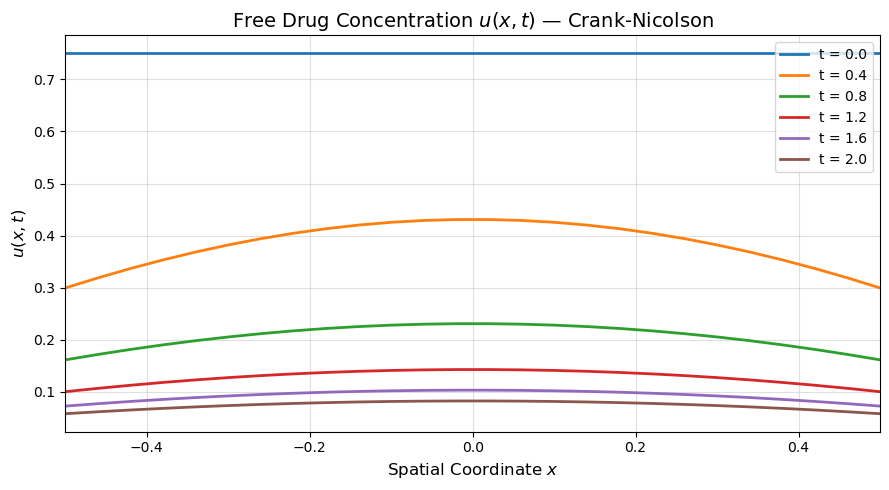

=> Drug concentration decreases over time as drug releases from the matrix.


In [10]:
# =============================================================
# Plot u(x,t) — Free Drug Concentration
# =============================================================

plt.figure(figsize=(9, 5))
for i, t_val in enumerate(t_eval):
    plt.plot(x, U_out[:, i], linewidth=2, label=f"t = {t_val:.1f}")
plt.title("Free Drug Concentration $u(x,t)$ — Crank-Nicolson", fontsize=14)
plt.xlabel("Spatial Coordinate $x$", fontsize=12)
plt.ylabel("$u(x,t)$", fontsize=12)
plt.xlim(xl, xu)
plt.grid(True, alpha=0.4)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("cn_u.png", dpi=150)
plt.show()
print("=> Drug concentration decreases over time as drug releases from the matrix.")

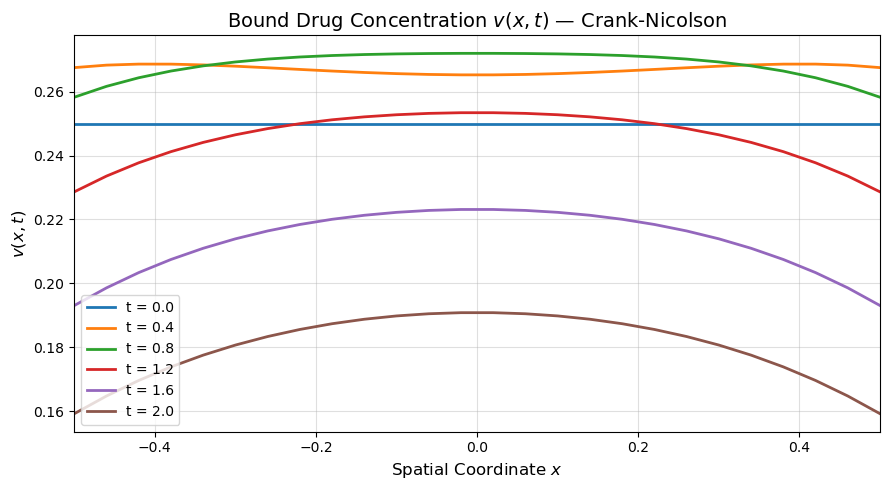

In [11]:
# =============================================================
# Plot v(x,t) — Bound Drug Concentration
# =============================================================

plt.figure(figsize=(9, 5))
for i, t_val in enumerate(t_eval):
    plt.plot(x, V_out[:, i], linewidth=2, label=f"t = {t_val:.1f}")
plt.title("Bound Drug Concentration $v(x,t)$ — Crank-Nicolson", fontsize=14)
plt.xlabel("Spatial Coordinate $x$", fontsize=12)
plt.ylabel("$v(x,t)$", fontsize=12)
plt.xlim(xl, xu)
plt.grid(True, alpha=0.4)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("cn_v.png", dpi=150)
plt.show()

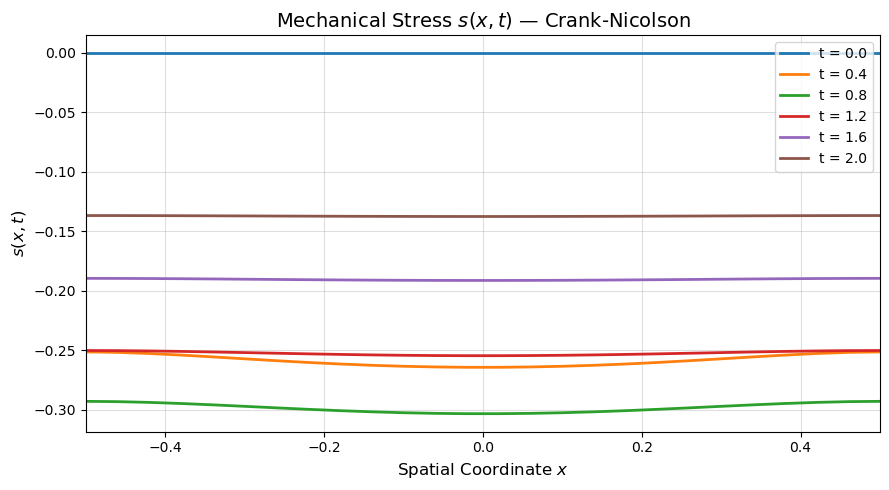

In [12]:
# =============================================================
# Plot s(x,t) — Mechanical Stress
# =============================================================

plt.figure(figsize=(9, 5))
for i, t_val in enumerate(t_eval):
    plt.plot(x, S_out[:, i], linewidth=2, label=f"t = {t_val:.1f}")
plt.title("Mechanical Stress $s(x,t)$ — Crank-Nicolson", fontsize=14)
plt.xlabel("Spatial Coordinate $x$", fontsize=12)
plt.ylabel("$s(x,t)$", fontsize=12)
plt.xlim(xl, xu)
plt.grid(True, alpha=0.4)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("cn_s.png", dpi=150)
plt.show()

## Step 9 — Side-by-Side Comparison: CN vs MOL

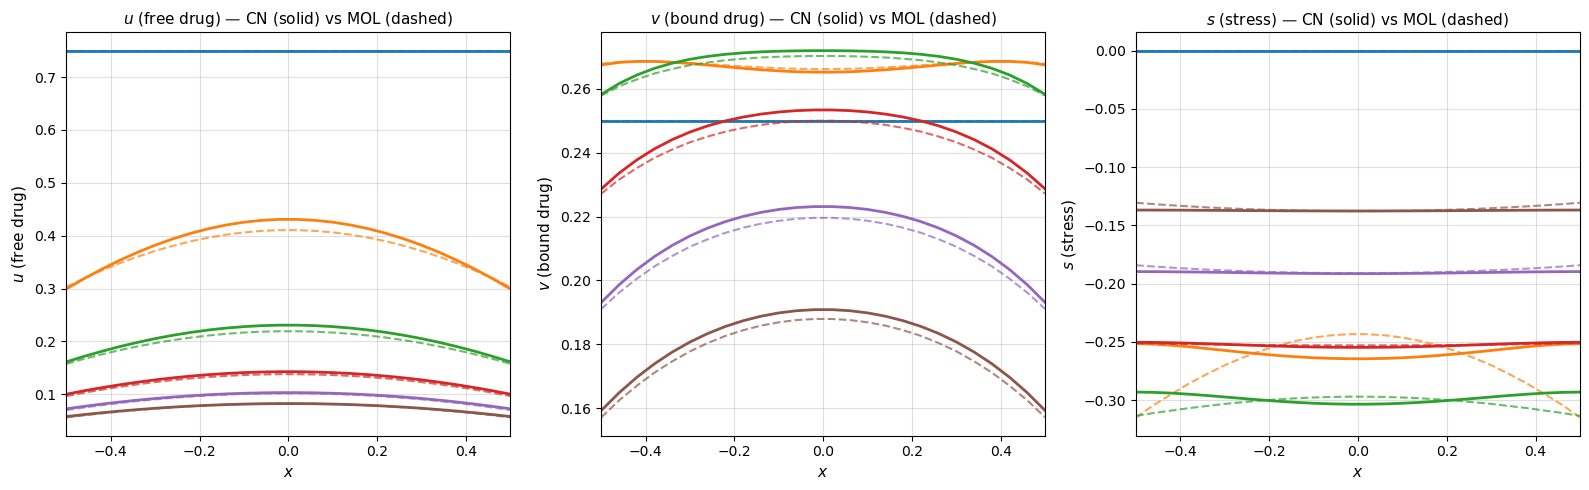

Solid lines = Crank-Nicolson | Dashed lines = MOL (RK45 reference)


In [13]:
# =============================================================
# Side-by-Side Comparison for u(x,t): CN vs MOL
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = ["$u$ (free drug)", "$v$ (bound drug)", "$s$ (stress)"]
cn_data  = [U_out, V_out, S_out]
mol_data = [u_mol, v_mol, s_mol]
colors   = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]

for ax, label, cn_arr, mol_arr in zip(axes, labels, cn_data, mol_data):
    for i, t_val in enumerate(t_eval):
        ax.plot(x, cn_arr[:, i],  color=colors[i], linewidth=2,   label=f"CN  t={t_val:.1f}")
        ax.plot(x, mol_arr[:, i], color=colors[i], linewidth=1.5, linestyle="--", alpha=0.7)
    ax.set_title(f"{label} — CN (solid) vs MOL (dashed)", fontsize=11)
    ax.set_xlabel("$x$", fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_xlim(xl, xu)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("cn_vs_mol_comparison.png", dpi=150)
plt.show()
print("Solid lines = Crank-Nicolson | Dashed lines = MOL (RK45 reference)")

## Step 10 — Summary & Key Takeaways

### What we did

| Step | Action |
|------|--------|
| 1 | Defined the same parameters as the book's MOL solution |
| 2 | Built the **two tridiagonal CN matrices** $A$ and $B$ (once, outside the loop) |
| 3 | At each time step: solved $A u^{n+1} = B u^n + \text{reaction} + \text{BC}$ |
| 4 | Updated $v$ with explicit Euler (no diffusion) |
| 5 | Updated $s$ with CN diffusion + approximated $du/dt$ |
| 6 | Compared with MOL reference solution |

### CN vs MOL — Key differences

| Property | MOL (book) | Crank-Nicolson |
|----------|-----------|----------------|
| Spatial discretization | Finite differences | Finite differences |
| Time integration | RK45 (adaptive explicit) | CN (implicit, fixed $\Delta t$) |
| Stability | Conditionally stable (step size limited) | **Unconditionally stable** |
| Accuracy in time | 4th-order | 2nd-order |
| Cost per step | 1 RHS evaluation | 2 linear solves |

### Why CN is useful
- **Stiff problems**: when the stability limit of explicit methods forces very small $\Delta t$, CN lets you use larger steps.
- **Long-time simulations**: CN's unconditional stability makes it reliable for extended time horizons.
- **Standard in biomedical/heat transfer PDE solvers** (e.g., bioheat equation, drug diffusion, oxygen transport).